# FIG 3
## Analysis of circular aperture data

In [1]:
import sys
sys.path.insert(0,'..')

from backpropcount import counting
from backpropcount import profile

import h5py
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Key directories
file_base_raw = "/global/cfs/cdirs/ncemhub/distiller/raw/2023.09.18"
file_base_counted = "/global/cfs/cdirs/ncemhub/distiller/counted/2023.09.18"
file_base_counted_gauss = "/pscratch/sd/j/jrenner1/counted_gauss"
file_base_counted_gauss_prior = "/pscratch/sd/j/jrenner1/counted_gauss_prior"

scan_groups = [[1531, 1532, 1533, 1534],  # 70 pA, 300 kV, 30 mrad
               [1535, 1536, 1537, 1538],  # 140 pA
               [1539, 1540, 1541, 1542],  # 280 pA
               [1543, 1544, 1545, 1546]]  # 560 pA
#scan_group_titles = ["30 pA", "60 pA", "120 pA", "240 pA"]
idbase = [12284, 12288, 12292, 12296] # base IDs for each scan group, for standard counted files
#clength = [68, 54, 43, 34]  # in mm
clength = [92, 74.3, 59.9, 47.3]  # in mm
radii = [280, 233, 185, 149]

th_single_elec = 10
baseline = 20.0
linear_nominal_amplitude = 33.63

#### Determine the single-electron "Gaussian" profile

Processing scan at /global/cfs/cdirs/ncemhub/distiller/raw/2023.09.18/data_scan0000001531.h5...


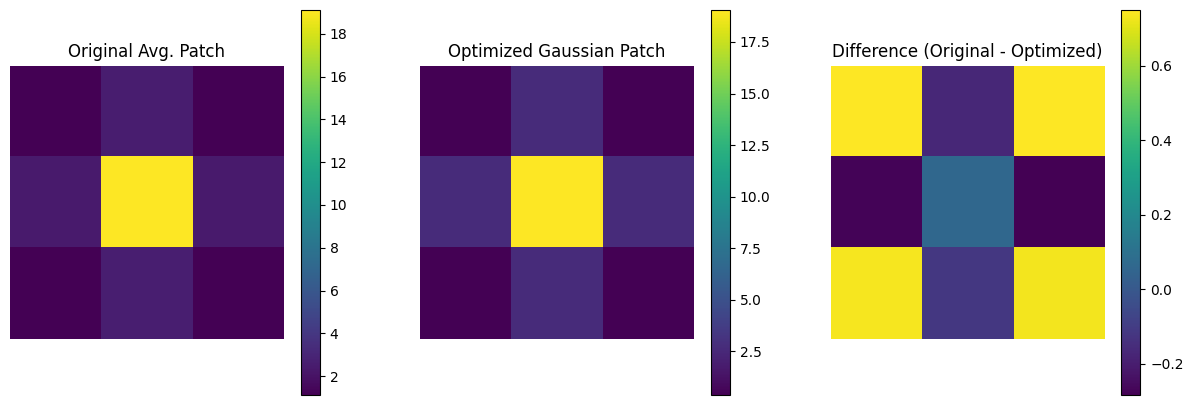

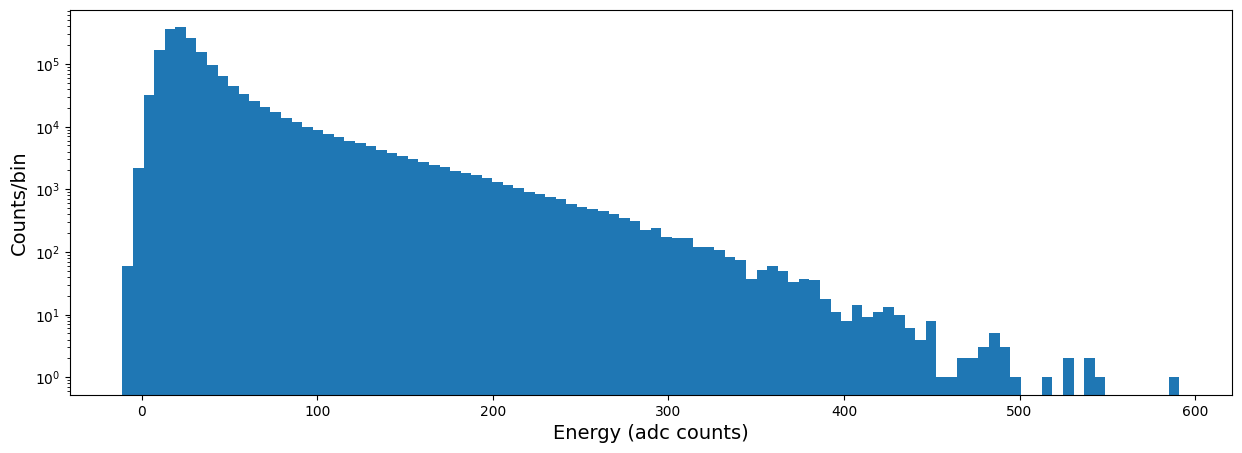

Determined optimal gaussian amplitude A = 19.049187704229617, sigma = 0.5063961567451579


In [3]:
nframes_profile = 1000
profile_scan = 1531
profile_file = f"{file_base_raw}/data_scan000000{profile_scan}.h5"
avg_patch, optimized_patch, A_opt, sigma_opt = profile.gaussian_profile(profile_file, nframes_profile, baseline, th_single_elec, plot_results=True)
print(f"Determined optimal gaussian amplitude A = {A_opt}, sigma = {sigma_opt}")

#### Perform the counting
Use the determined optimal values of A and sigma

In [4]:
nframes = -1
frame_width = 576
frames_per_batch = 2064
gauss_A = 19.032278788513683
gauss_sigma = 0.5065158171149362
n_steps_max = 10000
nframes_prior = 0

In [ ]:
# Count all datasets
for igroup in [3]:
    for iscan in [0,1,2]:
        raw_file = f"{file_base_raw}/data_scan000000{scan_groups[igroup][iscan]}.h5"
        print(f"Counting scan {iscan+1}/4 of group {igroup+1}/4: {raw_file}")
        counted_file = f"/pscratch/sd/j/jrenner1/counted_gauss/counted_gauss_scan000000{scan_groups[igroup][iscan]}.h5"
        #counted_file = f"/pscratch/sd/j/jrenner1/counted_gauss_prior/counted_gauss_prior_scan000000{scan_groups[igroup][iscan]}.h5"
        counting.count_frames(raw_file, counted_file, frames_per_batch, th_single_elec, baseline, gauss_A, gauss_sigma, n_steps_max = n_steps_max, nframes_prior = nframes_prior)

## Perform the analysis

In [5]:
frame_width = 576

In [6]:
# Function to convert linear indices to 2D (row, col) indices
def linear_to_2d_indices(linear_indices, cols):
    rows = linear_indices // cols
    cols = linear_indices % cols
    return rows, cols

# Function to create a 2D image from the counted frame data
def create_counted_image(frame_data, frame_height, frame_width, weight_data = None):
    # Initialize a 2D array with zeros
    image = np.zeros((frame_height, frame_width), dtype=np.int32)

    # Convert linear indices to 2D indices
    rows, cols = linear_to_2d_indices(frame_data, frame_width)

    # Set the hit pixels
    if(not(weight_data) is None):
        for r,c,w in zip(rows,cols,weight_data):
            image[r, c] = w
    else:
        image[rows,cols] = 1

    return image

def create_circular_mask(h, w, center=None, radius=None):
    if center is None:  # use the middle of the image
        center = (int(w/2), int(h/2))
    if radius is None:  # use the smallest distance between the center and image walls
        radius = min(center[0], center[1], w-center[0], h-center[1])

    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask

#### Raw aperture data

In [7]:
def calculate_fano_factor(counted_file, label, weights=False):
    """
    Calculates the Fano Factor (Var/Mean) for electron counts per frame.
    Ideal Poisson process has F = 1.
    """
    print(f"--- Calculating Fano Factor for {label} ---")
    with h5py.File(counted_file, 'r') as h5f:
        frames_grp = h5f['electron_events']['frames']
        nframes = len(frames_grp)
        
        counts_per_frame = np.zeros(nframes)
        
        # Check for weights
        weights_grp = None
        if weights and 'weights' in h5f['electron_events']:
            weights_grp = h5f['electron_events']['weights']

        for i in range(nframes):
            if weights_grp is not None:
                w = weights_grp[i]
                counts_per_frame[i] = np.sum(w) if len(w) > 0 else 0
            else:
                counts_per_frame[i] = len(frames_grp[i])

    mean_count = np.mean(counts_per_frame)
    var_count = np.var(counts_per_frame)
    fano = var_count / mean_count if mean_count > 0 else 0

    print(f"Mean Counts/Frame: {mean_count:.2f}")
    print(f"Variance:          {var_count:.2f}")
    print(f"Fano Factor:       {fano:.4f}")
    print("---------------------------------------")
    return fano

def calculate_analog_dqe0(raw_file, baseline, threshold, n_patches=1000):
    """
    Calculates Analog DQE(0) based on Pulse Height Distribution moments (McMullan 2009).
    DQE(0) = M1^2 / M2
    """
    print(f"--- Calculating Analog DQE(0) for {raw_file} ---")
    
    # Extract patches (using backpropcount library function)
    with h5py.File(raw_file, 'r') as f0:
        frames = f0['frames'][:n_patches].astype('float32')
    
    # Simple threshold-based patch extraction for statistics
    sub_frames = frames - baseline
    
    # Implement extraction using extracted_3x3 logic
    sub_frames_th = np.where(sub_frames >= threshold, sub_frames, 0)
    hit_patches = profile.extract_3x3_patches(sub_frames, sub_frames_th)
    
    # Calculate Moments
    # Integrate signal in each patch
    g_values = np.sum(hit_patches, axis=(1, 2))
    
    # Filter zeros
    g_values = g_values[g_values > 0]
    
    M1 = np.mean(g_values)
    M2 = np.mean(g_values**2)
    
    dqe0 = (M1**2) / M2
    print(f"Mean Signal (M1): {M1:.2f}")
    print(f"Mean Square (M2): {M2:.2f}")
    print(f"Analog DQE(0):    {dqe0:.4f}")
    print("---------------------------------------")
    return dqe0

# Use the lowest flux scan (1531 / 30 pA)
scan_30pA_raw = f"{file_base_raw}/data_scan0000001531.h5"
scan_30pA_counted_std = f"{file_base_counted}/data_scan1531_id12284_electrons.h5" 
# Note: BPC file path needs to be constructed carefully based on your notebook
scan_30pA_counted_bpc = f"{file_base_counted_gauss_prior}/counted_gauss_prior_scan0000001531.h5"

# 1. Calculate Analog DQE(0)
calculate_analog_dqe0(scan_30pA_raw, baseline=baseline, threshold=th_single_elec)

# 2. Calculate Fano Factors
calculate_fano_factor(scan_30pA_counted_std, "Standard Counting", weights=False)
calculate_fano_factor(scan_30pA_counted_bpc, "BPC (Prior)", weights=True)

--- Calculating Analog DQE(0) for /global/cfs/cdirs/ncemhub/distiller/raw/2023.09.18/data_scan0000001531.h5 ---
Mean Signal (M1): 33.63
Mean Square (M2): 2136.81
Analog DQE(0):    0.5292
---------------------------------------
--- Calculating Fano Factor for Standard Counting ---
Mean Counts/Frame: 1900.26
Variance:          4056.29
Fano Factor:       2.1346
---------------------------------------
--- Calculating Fano Factor for BPC (Prior) ---
Mean Counts/Frame: 1813.90
Variance:          2755.72
Fano Factor:       1.5192
---------------------------------------


np.float64(1.519226592379784)

Processing scan 1546...
Processing scan 1545...
Processing scan 1544...
Processing scan 1543...


/tmp/ipykernel_226065/1635347028.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


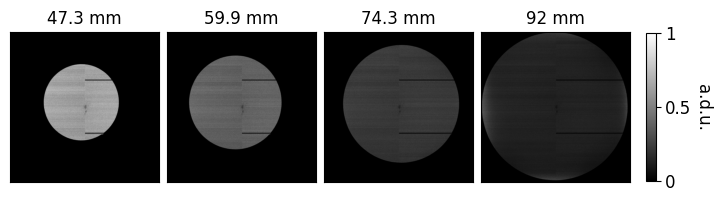

In [13]:
plt_group = 3
baselines = [20., 20., 20., 20.]
scan_nos = scan_groups[plt_group]

# Set up the figure
fig, axs = plt.subplots(1, 4, figsize=(8, 2), gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
fig.subplots_adjust(hspace=0.4)
axs = axs.flatten()

vmin = 0
vmax = 150000

for i, scan_no in enumerate(reversed(scan_nos)):
    print(f"Processing scan {scan_no}...")
    file_path = f"{file_base_raw}/data_scan000000{scan_no}.h5"
    with h5py.File(file_path, 'r') as f0:
        data = f0['frames']
    
        # Subtract the baseline and threshold.
        sub_frames = (data[0:nframes, :, :] - baselines[i])
        sub_frames[sub_frames < th_single_elec] = 0
        
        # Compute the sum of all frames.
        sum_frame = sub_frames.sum(axis=0)
        #sum_frame = np.ones([576,576])

        # Plotting of the ith subplot
        #imax = axs[i].imshow(sum_frame, vmin=sum_frame.min(), vmax=sum_frame.max(), cmap='gray')
        imax = axs[i].imshow(sum_frame / vmax, vmin=0, vmax=1.0, cmap='gray')
        axs[i].set_title(f'{clength[3-i]} mm',fontsize=12)
        axs[i].xaxis.set_visible(False)
        axs[i].yaxis.set_visible(False)

# Panel label
#axs[0].text(-0.15, 1.15, 'a', transform=axs[0].transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Place a single colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.125, 0.012, 0.74])  # Adjust position (left, bottom, width, height)
cbar = fig.colorbar(imax, cax=cbar_ax, orientation='vertical')
cbar.set_ticks([0, 0.5, 1])  # Set ticks for normalized values
cbar.set_ticklabels(['0', '0.5', '1'])  # Set tick labels
cbar.ax.tick_params(labelsize=12, direction='out')  # Adjust tick size and direction
cbar.set_label("a.d.u.", labelpad=15, rotation=270, fontsize=12)
#cbar.ax.text(4.0, 1.12, 'a.d.u.', fontsize=12, transform=cbar_ax.transAxes, ha='right', va='center')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(f'fig/fig3_circular_apertures_group{plt_group}.svg', bbox_inches='tight')

#### Counted aperture data

In [9]:
def sum_counts(file_path, frame_width, weights = False, plot_ax = None):
    
    with h5py.File(file_path, 'r') as f0:

        nframes = f0['electron_events']['frames'].shape[0] # get all frames
        print(f"Summing {nframes} frames...")
        summed_counted_image = np.zeros((frame_width, frame_width), dtype=np.int32)
        nelec = 0
        for iframe in range(nframes):
            #if(iframe % int(nframes/10) == 0):
            #    print(f"Processing frame {iframe}/{nframes}")
            frame_data = np.array(f0['electron_events']['frames'][iframe])
            weight_data = None
            if(weights):
                weight_data = np.array(f0['electron_events']['weights'][iframe])

            # Create a 2D image of the counted frame
            counted_image = create_counted_image(frame_data, frame_width, frame_width, weight_data)

            # Sum the counted images
            summed_counted_image += counted_image
            nelec += len(frame_data)

        # Plot the summed, counted image if an axis is specified.
        if(not(plot_ax is None)):
            imax = plot_ax.imshow(summed_counted_image, vmin=summed_counted_image.min(), vmax=summed_counted_image.max(), cmap='grey')
            #imax = axs[i].imshow(summed_counted_image[200:250,200:250], vmin=summed_counted_image.min(), vmax=summed_counted_image.max(), cmap='grey')
            fig.colorbar(imax, ax=axs[i])
            axs[i].set_title(f'Scan No: {scan_no}')
            
        return nelec, summed_counted_image

In [ ]:
# Process the standard counting for all groups.
counted_electrons_group = []
for igroup in range(4):
    
#     # Set up the figure
#     fig, axs = plt.subplots(1, 4, figsize=(10, 2))
#     axs = axs.flatten()
#     plt.tight_layout()
    
    counted_electrons = []
    for i, scan_no in enumerate(scan_groups[igroup]):

        print(f"Processing standard counting for scan {scan_no}...")
        file_path = f"{file_base_counted}/data_scan{scan_no}_id{idbase[igroup]+i}_electrons.h5"
        if(not os.path.isfile(file_path)):
            print(f"File {file_path} not found, skipping...")
            continue

        nelec, summed_counted_image = sum_counts(file_path, frame_width)# , axs[i])

        # Sum all the counts.
        print(f"-- Total counts: {np.sum(summed_counted_image)}")
        print(f"-- Total nelec:  {nelec}")
        counted_electrons.append(np.sum(summed_counted_image))
    
    # Save the counted electrons array for this entire scan group.
    counted_electrons_group.append(counted_electrons)
    
# Process the new counting for all groups.
new_base_counted_electrons_group = []
new_weighted_counted_electrons_group = []
for igroup in range(4):
    
    counted_electrons = []
    counted_electrons_weights = []
    for i, scan_no in enumerate(scan_groups[igroup]):

        print(f"Processing BPC without prior for scan {scan_no}...")
        file_path = f"{file_base_counted_gauss}/counted_gauss_scan000000{scan_no}.h5"
        if(not os.path.isfile(file_path)):
            print(f"File {file_path} not found, skipping...")
            continue

        nelec, summed_counted_image = sum_counts(file_path, frame_width)# , axs[i])
        nelec_weights, summed_counted_image_weights = sum_counts(file_path, frame_width, weights = True)

        # Sum all the counts.
        print(f"-- Total counts: {np.sum(summed_counted_image)}")
        print(f"-- Total nelec:  {nelec}")
        counted_electrons.append(np.sum(summed_counted_image))
        print(f"-- Total counts (weights): {np.sum(summed_counted_image_weights)}")
        print(f"-- Total nelec (weights):  {nelec_weights}")
        counted_electrons_weights.append(np.sum(summed_counted_image_weights))
    
    # Save the counted electrons array for this entire scan group.
    new_base_counted_electrons_group.append(counted_electrons)
    new_weighted_counted_electrons_group.append(counted_electrons_weights)
    
new_prior_counted_electrons_group = []
for igroup in range(4):
    
    counted_electrons = []
    counted_electrons_weights = []
    for i, scan_no in enumerate(scan_groups[igroup]):

        print(f"Processing BPC with prior for scan {scan_no}...")
        file_path = f"{file_base_counted_gauss_prior}/counted_gauss_prior_scan000000{scan_no}.h5"
        if(not os.path.isfile(file_path)):
            print(f"File {file_path} not found, skipping...")
            continue

        nelec, summed_counted_image = sum_counts(file_path, frame_width)# , axs[i])
        nelec_weights, summed_counted_image_weights = sum_counts(file_path, frame_width, weights = True)

        # Sum all the counts.
        print(f"-- Total counts: {np.sum(summed_counted_image)}")
        print(f"-- Total nelec:  {nelec}")
        counted_electrons.append(np.sum(summed_counted_image))
        print(f"-- Total counts (weights): {np.sum(summed_counted_image_weights)}")
        print(f"-- Total nelec (weights):  {nelec_weights}")
        counted_electrons_weights.append(np.sum(summed_counted_image_weights))
    
    # Save the counted electrons array for this entire scan group.
    #new_base_counted_electrons_group.append(counted_electrons)
    new_prior_counted_electrons_group.append(counted_electrons_weights)

In [ ]:
# Save the arrays for easier access
clength = np.array(clength)
counted_electrons_group = np.array(counted_electrons_group)
new_base_counted_electrons_group = np.array(new_base_counted_electrons_group)
new_weighted_counted_electrons_group = np.array(new_weighted_counted_electrons_group)
new_prior_counted_electrons_group = np.array(new_prior_counted_electrons_group)

np.savez("counted_arrays.npz", clength=clength,
         counted_electrons_group=counted_electrons_group, 
         new_base_counted_electrons_group=new_base_counted_electrons_group,
         new_weighted_counted_electrons_group=new_weighted_counted_electrons_group,
         new_prior_counted_electrons_group=new_prior_counted_electrons_group)

In [10]:
# Load the arrays
counted_arrays = np.load("counted_arrays.npz")
counted_electrons_group = counted_arrays['counted_electrons_group']
new_base_counted_electrons_group = counted_arrays['new_base_counted_electrons_group']
new_weighted_counted_electrons_group = counted_arrays['new_weighted_counted_electrons_group']
new_prior_counted_electrons_group = counted_arrays['new_prior_counted_electrons_group']

Calculated 2152.4818115286926 electrons/frame


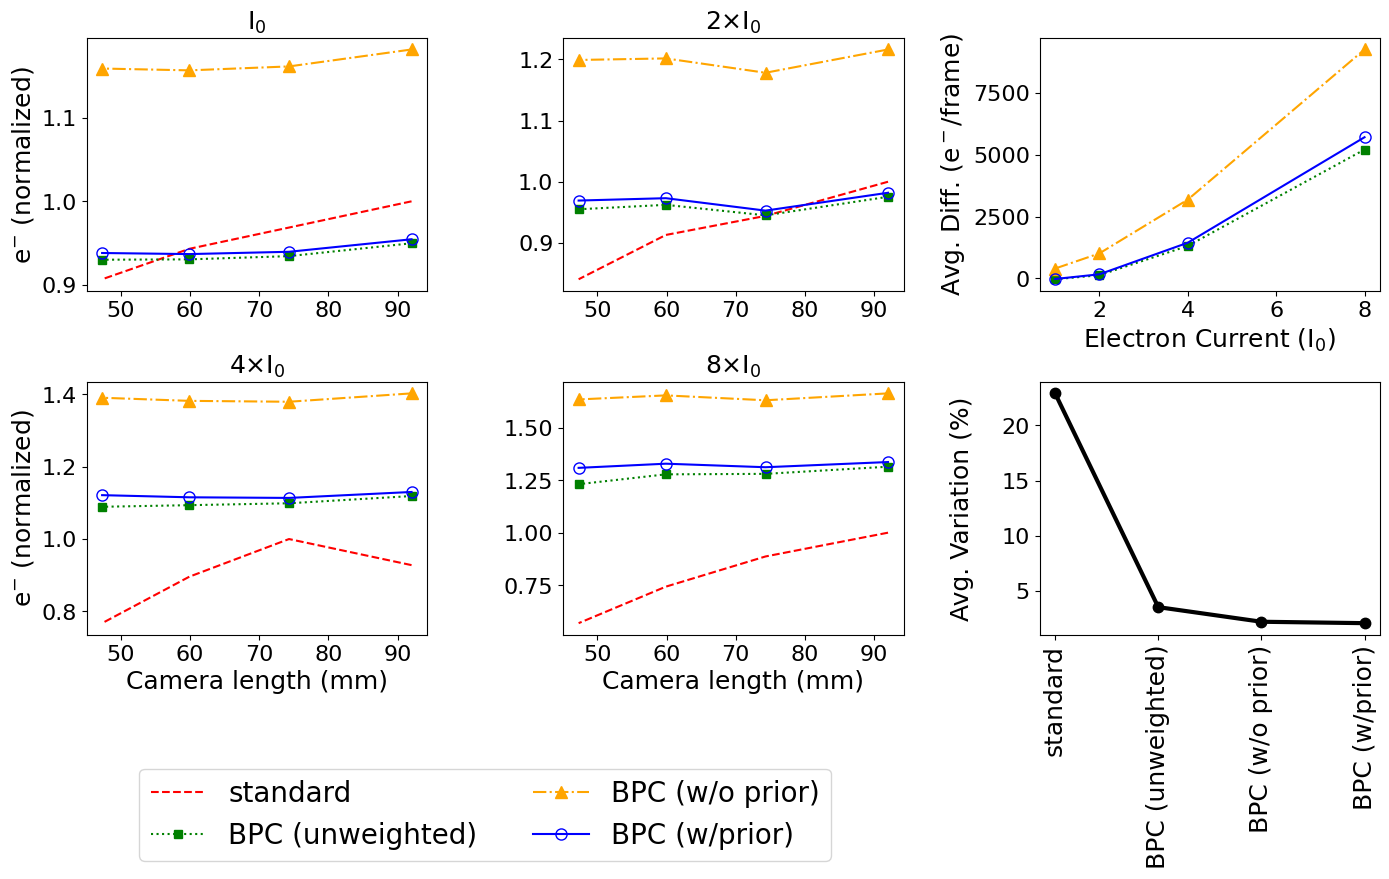

In [12]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

# Electron currents corresponding to the scan groups
#electron_currents = [70, 140, 280, 560] 
electron_currents = [1, 2, 4, 8]
calc_electrons_per_frame_base = 30e-12/1.602e-19/87000
print(f"Calculated {calc_electrons_per_frame_base} electrons/frame")

# Scan group titles
scan_group_titles = ["I$_0$", "2$\\times$I$_0$", "4$\\times$I$_0$", "8$\\times$I$_0$"]

# Color scheme
styles = {
        'MC Truth':         {'color': 'black',  'linestyle': '-',  'linewidth': 5, 'alpha': 0.3, 'label': 'MC truth'},
        'Standard':         {'color': 'red',    'linestyle': '--', 'linewidth': 1.5, 'label': 'standard'},
        'BPC (unweighted)': {'color': 'green',  'linestyle': ':',  'linewidth': 1.5, 'label': 'BPC (unweighted)', 'marker': 's', 'markersize': 6},
        'BPC (w/o prior)':  {'color': 'orange', 'linestyle': '-.', 'linewidth': 1.5, 'label': 'BPC (w/o prior)',  'marker': '^', 'markersize': 8},
        'BPC (w/prior)':    {'color': 'blue',   'linestyle': '-',  'linewidth': 1.5, 'label': 'BPC (w/prior)',    'marker': 'o', 'mfc': 'none', 'markersize': 8}
}

# Line and marker sizes
lwidth = 3
msize = 15

# Initialize lists to store the average differences and variations
avg_diffs_unweighted, avg_diffs_weighted, avg_diffs_prior = [], [], []
avg_variations = []

for igroup in range(4):
    naxis = igroup
    if(igroup > 1): naxis += 1
    
    max_count = np.max(counted_electrons_group[igroup])

    # Normalize counts
    norm_standard = counted_electrons_group[igroup] / max_count
    norm_standard_err = np.sqrt(counted_electrons_group[igroup]) / max_count
    norm_base = new_base_counted_electrons_group[igroup] / max_count
    norm_base_err = np.sqrt(new_base_counted_electrons_group[igroup]) / max_count
    norm_weighted = new_weighted_counted_electrons_group[igroup] / max_count
    norm_weighted_err = np.sqrt(new_weighted_counted_electrons_group[igroup]) / max_count
    norm_prior = new_prior_counted_electrons_group[igroup] / max_count
    norm_prior_err = np.sqrt(new_prior_counted_electrons_group[igroup]) / max_count

    # Plotting
    axs[naxis].plot(clength, norm_standard, **styles['Standard'])
    axs[naxis].plot(clength, norm_base, **styles['BPC (unweighted)'])
    axs[naxis].plot(clength, norm_weighted, **styles['BPC (w/o prior)'])
    axs[naxis].plot(clength, norm_prior, **styles['BPC (w/prior)'])
    #axs[naxis].axhline(calc_electrons_per_frame_base*electron_currents[igroup]*16512/max_count, linestyle='--', linewidth=lwidth, color='gray', label='Current-based\nestimate')
    
    # Error bars are so small they are invisible, but in case we wanted to plot them:
    # axs[naxis].errorbar(clength, norm_standard, yerr=norm_standard_err, marker='.', linestyle='-', color='red', label='Standard counting')
    # axs[naxis].errorbar(clength, norm_base, yerr=norm_base_err, marker='.', linestyle='-', color='green', label='New counting (no weights)')
    # axs[naxis].errorbar(clength, norm_weighted, yerr=norm_weighted_err, marker='.', linestyle='-', color='black', label='New counting (with weights)')
    # axs[naxis].errorbar(clength, norm_prior, yerr=norm_prior_err, marker='.', linestyle='-', color='blue', label='New counting (with prior)')

    # Set titles and labels
    axs[naxis].set_title(f"{scan_group_titles[igroup]}",fontsize=18) # ({max_count/16512:3.0f} cts/frame)", fontsize=14)
    axs[naxis].tick_params(axis='both', which='major', labelsize=16)
    if(igroup == 2 or igroup == 3):
        axs[naxis].set_xlabel("Camera length (mm)", fontsize=18)
    if(igroup == 0 or igroup == 2):
        axs[naxis].set_ylabel("e$^{-}$ (normalized)", fontsize=18)
    #axs[naxis].grid(True)
    
    # Calculate average difference between new (w/prior) and standard methods
    avg_diffs_unweighted.append(np.mean(norm_base - norm_standard)*max_count/16512)
    avg_diffs_weighted.append(np.mean(norm_weighted - norm_standard)*max_count/16512)
    avg_diffs_prior.append(np.mean(norm_prior - norm_standard)*max_count/16512)
    
    # Calculate percentage variations
    percent_var_standard = (np.max(norm_standard) - np.min(norm_standard)) / np.max(norm_standard) * 100
    percent_var_base = (np.max(norm_base) - np.min(norm_base)) / np.max(norm_base) * 100
    percent_var_weighted = (np.max(norm_weighted) - np.min(norm_weighted)) / np.max(norm_weighted) * 100
    percent_var_prior = (np.max(norm_prior) - np.min(norm_prior)) / np.max(norm_prior) * 100
    
    # Store the average variation for each curve
    avg_variation = np.array([percent_var_standard, percent_var_base, percent_var_weighted, percent_var_prior])
    avg_variations.append(avg_variation)
    
#axs[0].text(-0.2, 1.1, 'b', transform=axs[0].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

    # Display percentage variations
    # variation_text = (f"$\Delta$ "
    #                   f"Std: {percent_var_standard:.1f}%, "
    #                   f"No Wt: {percent_var_base:.1f}%, "
    #                   f"Wt: {percent_var_weighted:.1f}%, "
    #                   f"Prior: {percent_var_prior:.1f}%")
    # axs[igroup].text(0.5, 1.25, variation_text, transform=axs[igroup].transAxes,
    #                  fontsize=10, color='black', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8))

# Plot the average difference between new (weighted) and standard methods vs electron current
axs[2].plot(electron_currents, avg_diffs_unweighted, **styles['BPC (unweighted)'])
axs[2].plot(electron_currents, avg_diffs_weighted, **styles['BPC (w/o prior)'])
axs[2].plot(electron_currents, avg_diffs_prior, **styles['BPC (w/prior)'])
#axs[2].set_title("Avg. Difference [new (w/prior) - standard]", fontsize=14)
axs[2].set_xlabel("Electron Current (I$_0$)", fontsize=18)
axs[2].set_ylabel("Avg. Diff. (e$^-$/frame)", fontsize=18)
axs[2].tick_params(axis='both', which='major', labelsize=16)
#axs[2].grid(True)
#axs[2].text(-0.2, 1.1, 'c', transform=axs[2].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

# Plot the average variation in each curve vs electron current
method_names = ["standard", "BPC (unweighted)", "BPC (w/o prior)", "BPC (w/prior)"]
avg_variations = np.array(avg_variations)
avg_variations_mean = np.mean(avg_variations,axis=0)
avg_variations_sigma = np.std(avg_variations,axis=0)
axs[5].plot(method_names, avg_variations_mean, marker='.', markersize=msize, linestyle='-', linewidth=lwidth, color='black')
#axs[5].errorbar(method_names, avg_variations_mean, yerr=avg_variations_sigma/np.sqrt(avg_variations.shape[1]), marker='.', linestyle='-', color='brown')
#axs[5].set_title("Avg. Variation in Curves", fontsize=14)
#axs[5].set_xlabel("", fontsize=14)
axs[5].set_ylabel("Avg. Variation (%)", fontsize=18, labelpad=20)
axs[5].tick_params(axis='both', which='major', labelsize=16)
#axs[5].grid(True)
axs[5].set_xticks(range(len(method_names)))
axs[5].set_xticklabels(method_names, fontsize=18, rotation=90)
#axs[5].text(-0.2, 1.1, 'd', transform=axs[5].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

# Create a universal legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.35, -0.1), ncol=2, fontsize=20)

# ----------------------------------------------------------------------------------------------
# Add vertical separator line between the plots
# fig.subplots_adjust(wspace=0.4)  # Increase horizontal space between subplots

# Add a vertical line separator between the two groups of plots
# line_x_position = 2.0 / 3.0  # Position of the vertical line in normalized figure coordinates
# fig.subplots_adjust(left=0.1, right=0.9)  # Adjust figure size to make room for the line
# fig.add_artist(plt.Line2D([line_x_position, line_x_position], [0.1, 1.0], color='black', linewidth=1, transform=fig.transFigure))
# ----------------------------------------------------------------------------------------------

# Adjust the layout to make room for the legend and the separator line
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, wspace=0.4)

plt.savefig("fig/fig3_aperture_plots.svg", bbox_inches='tight')
plt.show()